In [245]:
# Importing packages
import numpy as np
import matplotlib.pyplot as plt 
import os

# Setting up a plotting directory in the repository
plot_dir = os.path.join("..", "plots", "eda")
os.makedirs(plot_dir, exist_ok=True)

In [246]:
""" Global parameters """

# Answer to the universe 
np.random.seed(42)

# Number of time periods
T = 1000

In [247]:
""" Implementing an Autoregreesive Hidden Markov Model with 1 state AR(1) """

# AR(1) parameters rho, sigma (variance), and P (transition matrix)
rho = np.array([0.2, 0.8])
sigma = np.array([0.5, 1.0])
P = np.array(
    [[0.95, 0.05],
    [0.05, 0.95]]
    )

# Initiating states and series value 
states = np.zeros(T, dtype=int)
y = np.zeros(T)

# Setting first state and series value
states[0] = np.random.choice([0,1])
y[0] = np.random.normal()

# Printing current values 
print(f"T:{T}")
print(f"rho: {rho}")
print(f"sigma:{sigma}\n")
print(f"P:\n {P}\n")
print(f"states[0]: {states[0]}")
print(f"y[0]: {y[0]}\n")

# Running through the AR(1) loop
for t in range(1, T):
    
    # States are chosen at random choice from either 0 or 1
    # given the transition matrix P in previous period t-1
    states[t] = np.random.choice([0,1], p=P[states[t-1]])

    # Saving the states to a variable s
    s = states[t]

    # The time series value depends on the rho parameter
    # times the last value plus random noise given state 
    y[t] = rho[s]*y[t-1] + np.random.normal(scale=sigma[s])

    # Printing out every 100th row to console
    if t % 100 == 0:
        col1 = f"iteration {t}"
        col2 = f"state: {s}"
        col3 = f"y[{t}]: {y[t]:.4f}"
        print(f"{col1:<20s}{col2:<15s}{col3}")


T:1000
rho: [0.2 0.8]
sigma:[0.5 1. ]

P:
 [[0.95 0.05]
 [0.05 0.95]]

states[0]: 0
y[0]: -0.5502344891639495

iteration 100       state: 1       y[100]: 2.1131
iteration 200       state: 1       y[200]: 0.6728
iteration 300       state: 0       y[300]: 0.0844
iteration 400       state: 1       y[400]: 1.8351
iteration 500       state: 0       y[500]: -0.0828
iteration 600       state: 1       y[600]: 4.2529
iteration 700       state: 0       y[700]: 0.2184
iteration 800       state: 1       y[800]: 0.6818
iteration 900       state: 1       y[900]: -3.4259


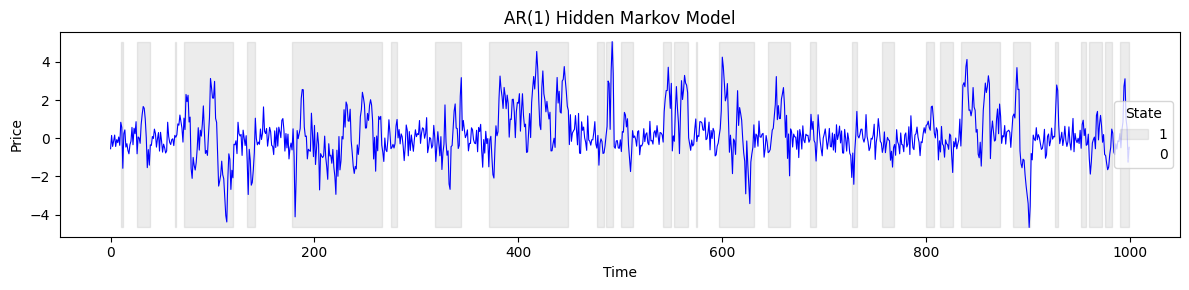

In [248]:
""" Plotting figure """

# Figure size 
plt.figure(figsize=(12,3))

# Plotting the line segments and filling in gaps
plt.plot(y, color="blue", linewidth=0.8)
plt.fill_between(range(T), y.min(), y.max(), where=(states==1), alpha=0.15, color="grey", label="1")
plt.fill_between(range(T), y.min(), y.max(), where=(states==0), alpha=0.15, color="white", label="0")

# Title, axes labels, and legend 
plt.title("AR(1) Hidden Markov Model")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend(title="State")

# Tight layout
plt.tight_layout()

# Saving and showing the figure
plt.savefig(os.path.join(plot_dir, "ar1-hmm.pdf"), bbox_inches="tight")
plt.show()

In [249]:
""" Autoregreesive Hidden Markov Model with k states AR(k) """

# Defining the function named ark; short of AR(k)
def ark(T, k, rho, sigma, P):

    # Asserting that the inputs are coherent with k states
    assert len(rho) == k, f"rho must be of length {k}"
    assert len(sigma) == k, f"sigma must be of length {k}"
    assert P.shape == (k, k), f"P must be a matrix {k}x{k}"
    assert np.allclose(P.sum(axis=1), 1), "P matrix rows must sum to 1.0"

    # Initiating states and series value 
    states = np.zeros(T, dtype=int)
    y = np.zeros(T)

    # Setting first state and series value
    states[0] = np.random.choice(k)
    y[0] = np.random.normal()

    # Looping through the T datapoints 
    for t in range(1, T):

        # State at time t is a random choice between k states
        states[t] = np.random.choice(k, p=P[states[t-1]])

        # Saving the state at time t to a variable s
        s = states[t]

        # The time series value y depends on rho of state at time t 
        # times the last time series value plus random noise  
        y[t] = rho[s] * y[t-1] + np.random.normal(scale=sigma[s])

    # Returning the states and the time series values y 
    return states, y

In [250]:
""" Inputting parameters for the AR(k) model """

# Number of states k
k = 4

# Rho and sigma parameters are a random uniform distribution
rho_params = np.random.uniform(-0.8, 0.8, k)
sigma_params = np.random.uniform(0.5, 2.0, k)

# Transition matrix chosen at a random dirichlet given states k
P_matrix = np.random.dirichlet(np.ones(k), size=k)

# Saving the simulated states and time series values given ark
simulated_states, simulated_y = ark(T, k, rho_params, sigma_params, P_matrix)

# Printing some values  
print(f"Rho parameters: {rho_params}")
print(f"Sigma parameters: {sigma_params}\n")
print(f"TIme steps: {T}")
print(f"States: {k}\n")
print(f"First 5 states:\n {simulated_states[:5]}")
print(f"First 5 y values:\n {np.round(simulated_y[:5], 4)}")

Rho parameters: [-0.6812146  -0.43783761  0.36839384  0.15809327]
Sigma parameters: [0.59673691 1.81585919 1.81589264 0.99561201]

TIme steps: 1000
States: 4

First 5 states:
 [0 2 1 0 1]
First 5 y values:
 [ 0.9752  1.2692 -5.4644  4.1269 -0.8787]


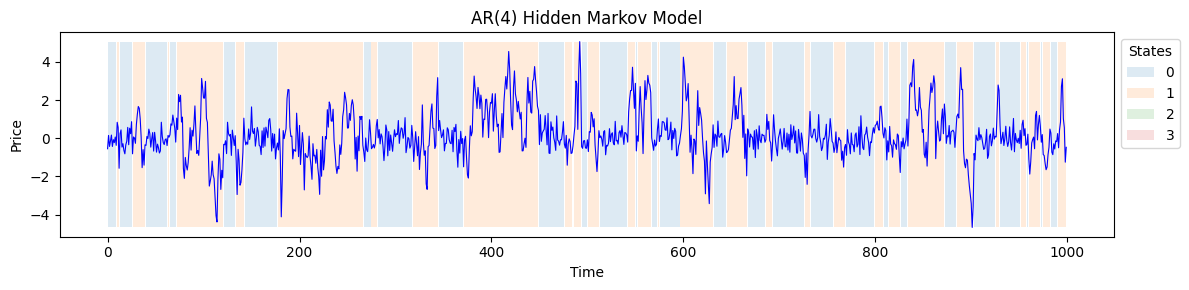

In [251]:
""" Plotting figure """

# Setting figure size
plt.figure(figsize=(12,3))

# Plotting the line segments and filling in gaps
plt.plot(y, color="blue", linewidth=0.8)

# Filling in between the hidden parts
for i in range(k):
    plt.fill_between(
        range(T), 
        y.min(), 
        y.max(), 
        where=(states == i), 
        alpha=0.15, 
        label=f"{i}"
    )

# Adding title, axes titles, and legend 
plt.title(f"AR({k}) Hidden Markov Model")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend(title="States", bbox_to_anchor=(1, 1))

# Tight layout
plt.tight_layout()

# Saving and showing the figure
plt.savefig(os.path.join(plot_dir, f"ar{k}-hmm.pdf"), bbox_inches="tight")
plt.show()